Mounted at /content/drive
Modelo crudo: reacciones y genes por sitio
Las_Docas       reacciones=5145     genes=265782
Algarrobo       reacciones=5696     genes=444330
Navidad         reacciones=4865     genes=185084
Topocalma       reacciones=5397     genes=400278
Ilque           reacciones=4473     genes=44266
San_Antonio     reacciones=5765     genes=203363
Pargua          reacciones=5750     genes=297633
Los_Chonos      reacciones=6008     genes=524751
Guardado (fondo blanco): /content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/COFACTORES/resultados/graficos_pre_curacion/Reacciones_genes_crudo.png
Guardado (fondo transparente, letras negras): /content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/COFACTORES/resultados/graficos_pre_curacion/Reacciones_genes_crudo_transparente.png


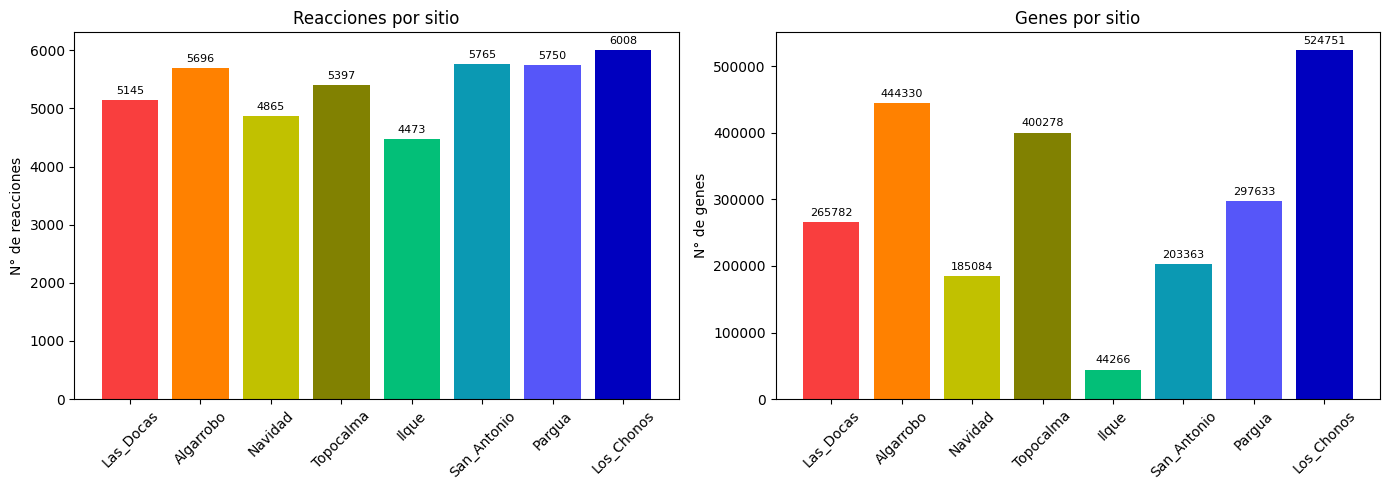

In [ ]:
## CUADERNILLO PARA REALIZAR CURACION (output: modelo "_cof_")
# buscar "#modificar" para cambiar rutas !!

# CELDA 1: montar drive + analisis preliminar de los 8 modelos crudos
from google.colab import drive
drive.mount('/content/drive')

import os, re
from lxml import etree

### MODELOS PRE CURACION

#modificar
MODELOS_1 = '/content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2'
SITIOS = ['Las_Docas', 'Algarrobo','Navidad','Topocalma','Ilque','San_Antonio','Pargua','Los_Chonos']

def buscar_sbml(carpeta):
    for f in os.listdir(carpeta):
        if f.endswith('.sbml'):
            return os.path.join(carpeta, f)
    raise FileNotFoundError(carpeta)


# COMANDO: contar_reacciones_genes('/content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1/Algarrobo/sbml/modelo.sbml')
# devuelve: (5696, 444330)

def contar_reacciones_genes(sbml_path):
    # recorre el archivo en modo streaming, sin cargarlo completo a memoria
    n_reacciones = 0
    genes = set()
    for event, elem in etree.iterparse(sbml_path, events=("end",), huge_tree=True):
        if etree.QName(elem).localname == "reaction":
            n_reacciones += 1
            texto = "".join(elem.itertext())
            m = re.search(r'GENE_ASSOCIATION:\s*(.*)', texto)
            if m:
                tokens = re.findall(r'[\w\.\-]+', m.group(1))
                genes.update(t for t in tokens if t.lower() not in ('and', 'or'))
            elem.clear()
    return n_reacciones, len(genes)

rutas_crudo = {}
print("Modelo crudo: reacciones y genes por sitio")
for sitio in SITIOS:
    path = buscar_sbml(os.path.join(MODELOS_1, sitio, 'sbml'))
    rutas_crudo[sitio] = path
    n_rxn, n_genes = contar_reacciones_genes(path)
    print(f"{sitio:<15} reacciones={n_rxn:<8} genes={n_genes}")


## GRAFICOS ---------------------------------------
import matplotlib.pyplot as plt

PALETA_SITIOS = {
    'Algarrobo':   '#ff8100',
    'Ilque':       '#03bf78',
    'Las_Docas':   '#f93e3e',
    'Los_Chonos':  '#0000bf',
    'Navidad':     '#c1c100',
    'Pargua':      '#5656f9',
    'San_Antonio': '#0b99b3',
    'Topocalma':   '#818101',
}

reacciones_por_sitio, genes_por_sitio = {}, {}
for sitio in SITIOS:
    n_rxn, n_genes = contar_reacciones_genes(rutas_crudo[sitio])
    reacciones_por_sitio[sitio] = n_rxn
    genes_por_sitio[sitio] = n_genes

colores = [PALETA_SITIOS[s] for s in SITIOS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

barras_rxn = axes[0].bar(SITIOS, [reacciones_por_sitio[s] for s in SITIOS], color=colores)
axes[0].set_title('Reacciones por sitio')
axes[0].set_ylabel('N° de reacciones')
axes[0].tick_params(axis='x', rotation=45)
axes[0].bar_label(barras_rxn, padding=3, fontsize=8)

barras_genes = axes[1].bar(SITIOS, [genes_por_sitio[s] for s in SITIOS], color=colores)
axes[1].set_title('Genes por sitio')
axes[1].set_ylabel('N° de genes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].bar_label(barras_genes, padding=3, fontsize=8)

plt.tight_layout()

# ---- Guardado: fondo blanco ----
#modificar
OUT_BASE = '/content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/COFACTORES/resultados/graficos_pre_curacion'
os.makedirs(OUT_BASE, exist_ok=True)

FIG_OUT_CRUDO = os.path.join(OUT_BASE, 'Reacciones_genes_crudo.png')
plt.savefig(FIG_OUT_CRUDO, dpi=300, bbox_inches='tight', transparent=False)
print(f"Guardado (fondo blanco): {FIG_OUT_CRUDO}")

# ---- Guardado: fondo transparente, letras negras ----
fig.patch.set_alpha(0.0)
for ax_ in axes:
    ax_.patch.set_alpha(0.0)

FIG_OUT_CRUDO_TRANSP = os.path.join(OUT_BASE, 'Reacciones_genes_crudo_transparente.png')
plt.savefig(FIG_OUT_CRUDO_TRANSP, dpi=300, bbox_inches='tight', transparent=True)
print(f"Guardado (fondo transparente, letras negras): {FIG_OUT_CRUDO_TRANSP}")

plt.show()

In [ ]:
# CELDA 2: curacion de cofactores (logica de Ulloa/Saadat) + ejemplos de reacciones duplicadas
import sys, re
from lxml import etree

### SCRIPT: /content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/COFACTORES/cofactores_metagenomas.py

#modificar
sys.path.insert(0, os.path.join(MODELOS_1, 'COFACTORES'))
from cofactores_metagenomas import curar_sbml

### TSV: /content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/COFACTORES/cofactors.tsv

#modificar
COFACTORS_TSV = os.path.join(MODELOS_1, 'COFACTORES', 'cofactors.tsv')


def decode_id(raw_id):
    s = re.sub(r"__(\d+)__", lambda m: chr(int(m.group(1))), raw_id)
    return s[2:] if s.startswith("M_") or s.startswith("R_") else s

### MODELOS POST CURACION

rutas_curado = {}
for sitio in SITIOS:
    input_sbml = rutas_crudo[sitio]
    #modificar
    output_sbml = os.path.join(MODELOS_1, sitio, 'sbml_curado', os.path.basename(input_sbml))
    stats = curar_sbml(input_sbml, COFACTORS_TSV, output_sbml, verbose=False)
    rutas_curado[sitio] = output_sbml

    # COMANDO: curar_sbml('.../Ilque/sbml/modelo.sbml', '.../cofactors_v2.tsv', '.../Ilque/sbml_curado/modelo.sbml')
    # devuelve: {'n_reactions_original': 4473, 'n_reactions_matched': 1298, 'n_new_species': 35}

    print(f"\n{sitio}: {stats['n_reactions_matched']} de {stats['n_reactions_original']} reacciones "
          f"tienen un par de cofactores, {stats['n_new_species']} especies __cof__ nuevas")

    # ejemplos: 10 reacciones duplicadas, para revisar visualmente que sean pares redox/energia reales
    root = etree.parse(output_sbml).getroot()
    especies_cof = {sp.get('id') for sp in root.find('.//{*}listOfSpecies').findall('{*}species')
                    if sp.get('id', '').endswith('__cof__')}
    contador = 0
    for r in root.find('.//{*}listOfReactions').findall('{*}reaction'):
        lr = r.find('{*}listOfReactants')
        lp = r.find('{*}listOfProducts')
        reactivos = [sr.get('species') for sr in lr] if lr is not None else []
        productos = [sr.get('species') for sr in lp] if lp is not None else []
        involucradas = especies_cof & (set(reactivos) | set(productos))
        if involucradas:
            print("   ", r.get('id'), "->", sorted(decode_id(e) for e in involucradas))
            contador += 1
        if contador >= 10:
            break


Las_Docas: 1642 de 5145 reacciones tienen un par de cofactores, 37 especies __cof__ nuevas
    R___45____45__LIMONENE__45__6__45__MONOOXYGENASE__45__RXN__cof__ -> ['Ox-NADPH-Hemoprotein-Reductases_c__cof__', 'Red-NADPH-Hemoprotein-Reductases_c__cof__']
    R___45____45__LIMONENE__45__7__45__MONOOXYGENASE__45__RXN__cof__ -> ['Ox-NADPH-Hemoprotein-Reductases_c__cof__', 'Red-NADPH-Hemoprotein-Reductases_c__cof__']
    R_1__45__PHOSPHATIDYLINOSITOL__45__3__45__KINASE__45__RXN__cof__ -> ['ADP_c__cof__', 'ATP_c__cof__']
    R_1__45__PHOSPHATIDYLINOSITOL__45__KINASE__45__RXN__cof__ -> ['ADP_c__cof__', 'ATP_c__cof__']
    R_1__46__1__46__1__46__127__45__RXN__cof__ -> ['NADH_c__cof__', 'NAD_c__cof__']
    R_1__46__1__46__1__46__136__45__RXN__cof__ -> ['NADH_c__cof__', 'NAD_c__cof__']
    R_1__46__1__46__1__46__178__45__RXN__cof__ -> ['NADH_c__cof__', 'NAD_c__cof__']
    R_1__46__1__46__1__46__191__45__RXN__cof__ -> ['NADPH_c__cof__', 'NADP_c__cof__']
    R_1__46__1__46__1__46__197__45__RXN__co

In [ ]:
# CELDA 3: reacciones y genes de los modelos ya curados
print("Modelo curado: reacciones y genes por sitio")
for sitio in SITIOS:
    n_rxn, n_genes = contar_reacciones_genes(rutas_curado[sitio])
    print(f"{sitio:<15} reacciones={n_rxn:<8} genes={n_genes}")

# COMANDO: contar_reacciones_genes(rutas_curado[Las_Docas])
# devuelve: (6691, 265782)

Modelo curado: reacciones y genes por sitio
Las_Docas       reacciones=6787     genes=265782
Algarrobo       reacciones=7487     genes=444330
Navidad         reacciones=6391     genes=185084
Topocalma       reacciones=7139     genes=400278
Ilque           reacciones=5854     genes=44266
San_Antonio     reacciones=7584     genes=203363
Pargua          reacciones=7519     genes=297633
Los_Chonos      reacciones=7915     genes=524751


In [ ]:
# CELDA 4: revisar la semilla de cofactores y probar el scope con mene scope

# instalar menetools y el solver clingo (una sola vez por sesion de Colab)
import subprocess, shutil
subprocess.run(["pip", "install", "-q", "menetools", "clyngor-with-clingo"])
print("clingo encontrado en:", shutil.which("clingo"))

# COMANDO: run_mene_scope(rutas_curado[sitio], SEED_COFACTORES)
# devuelve: set de Python con 40 metabolitos

def run_mene_scope(sbml_path, seed_path):
    tmp_out = tempfile.NamedTemporaryFile(suffix='.json', delete=False).name
    cmd = f'mene scope -d "{sbml_path}" -s "{seed_path}" --output "{tmp_out}"'
    resultado = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=900)
    if resultado.returncode != 0 or os.path.getsize(tmp_out) == 0:
        print("mene scope fallo:")
        print(resultado.stderr[-1000:])
        return None
    with open(tmp_out) as f:
        return set(json.load(f).get('scope', []))

import subprocess, json, tempfile
from lxml import etree

# SEED: /content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/COFACTORES/seed_cofactors.sbml

#modificar
SEED_COFACTORES = os.path.join(MODELOS_1, 'COFACTORES', 'seed_cofactors.sbml')


especies_semilla = [sp.get('id') for sp in etree.parse(SEED_COFACTORES).getroot()
                    .find('.//{*}listOfSpecies').findall('{*}species')]
print(f"La semilla tiene {len(especies_semilla)} especies. Primeras 10, para revisar visualmente el formato:")
for e in especies_semilla[:10]:
    print("   ", e)

def run_mene_scope(sbml_path, seed_path):
    tmp_out = tempfile.NamedTemporaryFile(suffix='.json', delete=False).name
    cmd = f'mene scope -d "{sbml_path}" -s "{seed_path}" --output "{tmp_out}"'
    subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=900)
    with open(tmp_out) as f:
        return set(json.load(f).get('scope', []))

print("\nCoincidencia de la semilla con cada modelo curado, y scope obtenido:")
import pandas as pd

print("\nCoincidencia de la semilla con cada modelo curado, y scope obtenido:")

resumen_scope = []       # tabla resumen: sitio, coincide, total_semilla, scope_total
scopes_por_sitio = {}    # guarda el set completo de cada sitio, para listar despues

for sitio in SITIOS:
    especies_modelo = {sp.get('id') for sp in etree.parse(rutas_curado[sitio]).getroot()
                        .find('.//{*}listOfSpecies').findall('{*}species')}
    coinciden = set(especies_semilla) & especies_modelo
    scope = run_mene_scope(rutas_curado[sitio], SEED_COFACTORES)

    if scope is None:
        resumen_scope.append({
            'sitio': sitio,
            'semilla_coincide': len(coinciden),
            'semilla_total': len(especies_semilla),
            'scope_total': None,
        })
        scopes_por_sitio[sitio] = None
        continue

    resumen_scope.append({
        'sitio': sitio,
        'semilla_coincide': len(coinciden),
        'semilla_total': len(especies_semilla),
        'scope_total': len(scope),
    })
    scopes_por_sitio[sitio] = scope

# ---- TABLA RESUMEN ----
df_scope = pd.DataFrame(resumen_scope)
print("\n" + "=" * 60)
print("RESUMEN: scope alcanzado por sitio (semilla seed_cofactors)")
print("=" * 60)
print(df_scope.to_string(index=False))


clingo encontrado en: /usr/local/bin/clingo
La semilla tiene 57 especies. Primeras 10, para revisar visualmente el formato:
    M_ATP_c__cof__
    M_ADP_c__cof__
    M_AMP_c__cof__
    M_GTP_c__cof__
    M_GDP_c__cof__
    M_ATP_p__cof__
    M_ADP_p__cof__
    M_GTP_p__cof__
    M_GDP_p__cof__
    M_ATP_e__cof__

Coincidencia de la semilla con cada modelo curado, y scope obtenido:

Coincidencia de la semilla con cada modelo curado, y scope obtenido:

RESUMEN: scope alcanzado por sitio (semilla seed_cofactors)
      sitio  semilla_coincide  semilla_total  scope_total
  Las_Docas                37             57          944
  Algarrobo                37             57         1006
    Navidad                37             57          902
  Topocalma                37             57          995
      Ilque                37             57          720
San_Antonio                37             57         1020
     Pargua                37             57         1000
 Los_Chonos          

In [ ]:

# ---- LISTADO DE METABOLITOS, sitio por sitio ----
for sitio in SITIOS:
    scope = scopes_por_sitio[sitio]
    print(f"\n{'='*50}")
    print(f"SITIO: {sitio}")
    if scope is None:
        print("  (falló mene scope, revisar arriba)")
        continue
    print(f"Metabolitos en el Scope ({len(scope)}):")
    for met in sorted(scope):
        print(f"  - {met}")


SITIO: Las_Docas
Metabolitos en el Scope (944):
  - M_1__45__AMINO__45__PROPAN__45__2__45__ONE__45__3__45__PHOSPHATE_c
  - M_1__45__KETO__45__2__45__METHYLVALERATE_c
  - M_1__45__L__45__MYO__45__INOSITOL__45__1__45__P_c
  - M_2C__45__METH__45__D__45__ERYTHRITOL__45__CYCLODIPHOSPHATE_c
  - M_2K__45__4CH3__45__PENTANOATE_c
  - M_2K__45__ADIPATE_c
  - M_2__45__ACETO__45__2__45__HYDROXY__45__BUTYRATE_c
  - M_2__45__ACETO__45__LACTATE_c
  - M_2__45__AMINOBENZOYL__45__COA_c
  - M_2__45__C__45__METHYL__45__D__45__ERYTHRITOL__45__4__45__PHOSPHATE_c
  - M_2__45__DEHYDRO__45__3__45__DEOXY__45__D__45__GALACTONATE_c
  - M_2__45__DEHYDRO__45__3__45__DEOXY__45__D__45__GLUCONATE_c
  - M_2__45__DH__45__3__45__DO__45__D__45__ARABINONATE_c
  - M_2__45__D__45__THREO__45__HYDROXY__45__3__45__CARBOXY__45__ISOCAPROATE_c
  - M_2__45__HYDROXYGLUTARYL__45__COA_c
  - M_2__45__KETOGLUTARATE_c
  - M_2__45__KETO__45__3__45__DEOXY__45__6__45__P__45__GLUCONATE_c
  - M_2__45__KETO__45__3__45__METHYL__45__VALERATE_c


In [ ]:
# CELDA 5: correr el scope de las 8 semillas contra los modelos PRE y POST curacion, para los 8 sitios

# demora como 7 minutos en correr !!!!

import glob
import pandas as pd
import os

# SEMILLAS: /content/drive/MyDrive/TESIS_CA/Pipeline/Intentos/MODELOS_1_v2/SCOPE/semillas

#modificar
SEMILLAS_DIR = os.path.join(MODELOS_1, 'SCOPE', 'semillas')
rutas_semillas = sorted(glob.glob(os.path.join(SEMILLAS_DIR, '*.sbml')))

print(f"Semillas encontradas ({len(rutas_semillas)}):")
for s in rutas_semillas:
    print("   ", os.path.basename(s))

# reutiliza run_mene_scope definido en la Celda 4
resultados = []  # lista de dicts: sitio, semilla, scope_crudo, scope_curado
total_corridas = len(SITIOS) * len(rutas_semillas) * 2
corrida = 0

for sitio in SITIOS:
    for seed_path in rutas_semillas:
        nombre_semilla = os.path.basename(seed_path).replace('.sbml', '')

        corrida += 1
        print(f"[{corrida}/{total_corridas}] {sitio} | {nombre_semilla} | crudo...")
        scope_crudo = run_mene_scope(rutas_crudo[sitio], seed_path)

        corrida += 1
        print(f"[{corrida}/{total_corridas}] {sitio} | {nombre_semilla} | curado...")
        scope_curado = run_mene_scope(rutas_curado[sitio], seed_path)

        resultados.append({
            'sitio': sitio,
            'semilla': nombre_semilla,
            'scope_crudo': len(scope_crudo) if scope_crudo is not None else None,
            'scope_curado': len(scope_curado) if scope_curado is not None else None,
        })

# tabla resumen
df = pd.DataFrame(resultados)
df['diferencia'] = df['scope_curado'] - df['scope_crudo']

print("\n" + "=" * 70)
print("RESUMEN: scope pre-curacion vs post-curacion, por sitio y semilla")
print("=" * 70)

pd.set_option('display.max_rows', None)
print(df.to_string(index=False))

# pivote para comparar semillas entre sitios de un vistazo (scope curado)
print("\nScope CURADO (filas=sitio, columnas=semilla):")
print(df.pivot(index='sitio', columns='semilla', values='scope_curado').to_string())

print("\nScope CRUDO (filas=sitio, columnas=semilla):")
print(df.pivot(index='sitio', columns='semilla', values='scope_crudo').to_string())

# guardar la tabla completa en el drive para no tener que re-correr todo
CSV_OUT = os.path.join(MODELOS_1, 'COFACTORES','resultados', 'scope_pre_post_curacion.csv')
df.to_csv(CSV_OUT, index=False)
print(f"\nTabla guardada en: {CSV_OUT}")

Semillas encontradas (8):
    seed_DIC.sbml
    seed_DICAlginate.sbml
    seed_DICGAPPyruvate.sbml
    seed_DICManitol.sbml
    seed_DICNH4.sbml
    seed_DICNO2.sbml
    seed_DICNO3.sbml
    seed_Full.sbml
[1/128] Las_Docas | seed_DIC | crudo...
[2/128] Las_Docas | seed_DIC | curado...
[3/128] Las_Docas | seed_DICAlginate | crudo...
[4/128] Las_Docas | seed_DICAlginate | curado...
[5/128] Las_Docas | seed_DICGAPPyruvate | crudo...
[6/128] Las_Docas | seed_DICGAPPyruvate | curado...
[7/128] Las_Docas | seed_DICManitol | crudo...
[8/128] Las_Docas | seed_DICManitol | curado...
[9/128] Las_Docas | seed_DICNH4 | crudo...
[10/128] Las_Docas | seed_DICNH4 | curado...
[11/128] Las_Docas | seed_DICNO2 | crudo...
[12/128] Las_Docas | seed_DICNO2 | curado...
[13/128] Las_Docas | seed_DICNO3 | crudo...
[14/128] Las_Docas | seed_DICNO3 | curado...
[15/128] Las_Docas | seed_Full | crudo...
[16/128] Las_Docas | seed_Full | curado...
[17/128] Algarrobo | seed_DIC | crudo...
[18/128] Algarrobo | seed_